# Notebook 03 — Multimodal Classifier (TF-IDF + CNN)
**Spendly AI — Coding Camp 2026 powered by DBS Foundation (CC26-PSU276)**

**v3 Changes (dari v2):**
- CNN branch diperdalam: 4 Conv block + SEBlock (custom layer) per block
- Image augmentation di tf.data pipeline (flip, brightness, contrast, rotation)
- Augmentasi OCR noise di text branch saat training agar robust terhadap output CRNN
- FocalLoss diupdate: support per-class alpha dari class_weights
- SpendlyCallback di-wire ke tf.GradientTape manual loop via on_epoch_end_manual()
- Class weights dihitung dari distribusi aktual training data

In [1]:
import sys
!{sys.executable} -m pip install "numpy<2.0.0" --force-reinstall

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [2]:
import os, sys, time, re, random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import cv2
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

LABELS = [
    "Beauty", "F&B", "Gas", "Groceries",
    "Health", "HouseHold", "Lifestyle", "Listrik", "transport"
]
LABEL_TO_IDX = {lbl: i for i, lbl in enumerate(LABELS)}
NUM_CLASSES  = len(LABELS)  # 9
IMG_SIZE     = 224

print(f"Kategori ({NUM_CLASSES}): {LABELS}")

TensorFlow: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Kategori (9): ['Beauty', 'F&B', 'Gas', 'Groceries', 'Health', 'HouseHold', 'Lifestyle', 'Listrik', 'transport']


In [3]:
import subprocess

gpus = tf.config.list_physical_devices('GPU')
print(f"Jumlah GPU terdeteksi TF: {len(gpus)}")
for gpu in gpus:
    print(f"  Device: {gpu.name}")

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print("\nnvidia-smi GPU info:")
    for line in result.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"nvidia-smi tidak tersedia: {e}")

print(f"\nGPU aktif untuk TF: {tf.test.gpu_device_name()}")


Jumlah GPU terdeteksi TF: 1
  Device: /physical_device:GPU:0

nvidia-smi GPU info:
  0, NVIDIA GeForce RTX 3060 Ti, 8192 MiB, 6696 MiB

GPU aktif untuk TF: /device:GPU:0


In [4]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Enable mixed precision for better GPU memory usage
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f'Mixed precision policy: {policy.name}')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Ti, compute capability 8.6
Mixed precision policy: mixed_float16


## 3.1 — Load dataset_text.csv & split_manifest.csv

In [5]:
dataset_text = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', '_processed', 'dataset_text.csv'))
manifest     = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', '_csv', 'split_manifest.csv'))

has_blur       = 'is_blurry' in dataset_text.columns
has_image_path = 'image_path' in dataset_text.columns
filepath_col   = 'image_path' if has_image_path else 'filepath'

print(f"Dataset text : {len(dataset_text)} rows")
print(f"Has blur info: {has_blur}")
if has_blur:
    print(f"  Blurry images: {dataset_text['is_blurry'].sum()}/{len(dataset_text)}")
has_text_count = (dataset_text['extracted_text'].fillna('').str.len() > 0).sum()
print(f"Has text     : {has_text_count}/{len(dataset_text)}")

dataset_text['filepath_norm'] = dataset_text[filepath_col].apply(
    lambda x: os.path.normpath(str(x)).lower())
manifest['filepath_norm'] = manifest['filepath'].apply(
    lambda x: os.path.normpath(str(x)).lower())

manifest_orig = (
    manifest[manifest.get('augmented', False) == False].copy()
    if 'augmented' in manifest.columns else manifest.copy()
)
merged = dataset_text.merge(
    manifest_orig[['filepath_norm', 'split']], on='filepath_norm', how='left')
merged['split']          = merged['split'].fillna('train')
merged['extracted_text'] = merged['extracted_text'].fillna('').astype(str)
if has_blur:
    merged['is_blurry'] = merged['is_blurry'].fillna(False)

print(f"\nAll rows: {len(merged)}")
print(merged['split'].value_counts())
print(merged['category'].value_counts())

cats_in_data = set(merged['category'].unique())
cats_missing = cats_in_data - set(LABELS)
if cats_missing:
    print(f"\n⚠️  Kategori di data tapi tidak di LABELS: {cats_missing}")
else:
    print(f"\n✅ Semua kategori di data ada di LABELS ({NUM_CLASSES} kelas)")

Dataset text : 825 rows
Has blur info: True
  Blurry images: 6/825
Has text     : 817/825

All rows: 825
split
train    577
test     124
val      124
Name: count, dtype: int64
category
Groceries    251
F&B          141
transport    132
Gas           62
Listrik       62
Beauty        57
Health        40
HouseHold     40
Lifestyle     40
Name: count, dtype: int64

✅ Semua kategori di data ada di LABELS (9 kelas)


## 3.1b — NLP Preprocessing Pipeline (Bahasa Indonesia)

In [6]:
from custom_components import NLPPreprocessor

nlp_preprocessor = NLPPreprocessor()
print('✅ NLPPreprocessor siap (Sastrawi stopword + stemmer)')

save_dir = os.path.join(PROJECT_ROOT, 'models', 'classifier')
os.makedirs(save_dir, exist_ok=True)
joblib.dump(nlp_preprocessor, os.path.join(save_dir, 'nlp_preprocessor.joblib'))
print(f'✅ NLPPreprocessor saved: models/classifier/nlp_preprocessor.joblib')

✅ NLPPreprocessor siap (Sastrawi stopword + stemmer)
✅ NLPPreprocessor saved: models/classifier/nlp_preprocessor.joblib


## 3.1c — OCR Noise Augmentation untuk Text Branch

Text branch dilatih dengan teks dari EasyOCR (relatif bersih), tapi saat inference
menerima output CRNN yang noisy. Fungsi ini mensimulasikan noise CRNN saat training
agar text branch robust terhadap kesalahan OCR di production.

In [7]:
CHARSET = list('abcdefghijklmnopqrstuvwxyz0123456789 ')

def augment_ocr_noise(text: str, noise_prob: float = 0.15, seed: int = None) -> str:
    """Simulasikan output CRNN yang noisy pada teks bersih EasyOCR.

    Tiga jenis noise:
    - Drop karakter  (prob = noise_prob * 0.4)
    - Substitusi     (prob = noise_prob * 0.3  → total 0.7)
    - Insertion      (prob = noise_prob * 0.3  → total 1.0)

    Args:
        text       : teks input (sudah NLP preprocessed)
        noise_prob : probabilitas noise per karakter
        seed       : optional random seed untuk reprodusibilitas
    Returns:
        str: teks dengan noise injected
    """
    if not text or noise_prob <= 0:
        return text
    if seed is not None:
        random.seed(seed)

    result = []
    for c in text:
        r = random.random()
        if r < noise_prob * 0.4:
            pass                                          # drop
        elif r < noise_prob * 0.7:
            result.append(random.choice(CHARSET))         # substitusi
        elif r < noise_prob:
            result.append(c)
            result.append(random.choice(CHARSET))         # insertion
        else:
            result.append(c)                              # keep
    return ''.join(result)

def augment_texts_batch(texts, noise_prob=0.15, apply=True):
    """Apply augment_ocr_noise ke batch teks. Hanya dipakai saat training."""
    if not apply:
        return texts
    return [augment_ocr_noise(t, noise_prob=noise_prob) for t in texts]

# Sanity check
sample = "pln prabayar NUM NUM NUM"
print(f"Original  : {sample}")
print(f"With noise: {augment_ocr_noise(sample, noise_prob=0.20)}")
print("✅ augment_ocr_noise siap")

Original  : pln prabayar NUM NUM NUM
With noise: pln pbayr NUM UM NUM
✅ augment_ocr_noise siap


## 3.2 — TF-IDF Vectorization + Image Loading

In [8]:
MAX_FEATURES = 5000

train_data = merged[merged['split'] == 'train']
val_data   = merged[merged['split'] == 'val']
test_data  = merged[merged['split'] == 'test']

if len(val_data) < 10 or len(test_data) < 10:
    print("Val/Test too small — re-splitting...")
    from sklearn.model_selection import train_test_split
    train_data, temp = train_test_split(
        merged, test_size=0.3, stratify=merged['category'], random_state=SEED)
    val_data, test_data = train_test_split(
        temp, test_size=0.5, stratify=temp['category'], random_state=SEED)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# ── NLP Preprocessing ──────────────────────────────────────────────────────
print('Menjalankan NLP preprocessing...')
train_texts_nlp = nlp_preprocessor.preprocess_batch(
    train_data['extracted_text'].fillna('').tolist())
val_texts_nlp   = nlp_preprocessor.preprocess_batch(
    val_data['extracted_text'].fillna('').tolist())
test_texts_nlp  = nlp_preprocessor.preprocess_batch(
    test_data['extracted_text'].fillna('').tolist())

# ── Augmentasi OCR noise HANYA pada training texts ─────────────────────────
# Val dan test tidak di-augmentasi agar evaluasi mencerminkan kondisi nyata
train_texts_aug = augment_texts_batch(train_texts_nlp, noise_prob=0.15, apply=True)
print(f"  Contoh teks asli : {train_texts_nlp[0][:60]}")
print(f"  Contoh teks noisy: {train_texts_aug[0][:60]}")

# ── TF-IDF fit hanya pada teks asli (bukan augmented) ──────────────────────
# Fit di teks asli agar vocabulary stabil, transform di augmented
tfidf        = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2), sublinear_tf=True)
tfidf.fit(train_texts_nlp)   # fit di original

X_train_text = tfidf.transform(train_texts_aug).toarray().astype(np.float32)  # augmented
X_val_text   = tfidf.transform(val_texts_nlp).toarray().astype(np.float32)
X_test_text  = tfidf.transform(test_texts_nlp).toarray().astype(np.float32)

actual_features = X_train_text.shape[1]
print(f"TF-IDF features: {actual_features}")

if has_blur:
    X_train_text[train_data['is_blurry'].values] = 0.0
    X_val_text  [val_data['is_blurry'].values]   = 0.0
    X_test_text [test_data['is_blurry'].values]  = 0.0
    print(f"Zeroed text for blurry images")

joblib.dump(tfidf, os.path.join(save_dir, 'tfidf_vectorizer.joblib'))
print("✅ TF-IDF vectorizer saved.")

Train: 577, Val: 124, Test: 124
Menjalankan NLP preprocessing...
  Contoh teks asli : NUM df tlk npap indy park gedun lanta dan jalan houlcvand bi
  Contoh teks noisy: NUM f tlk npap indy park h8dhn langadanyjaan houlcaad inlro 
TF-IDF features: 5000
Zeroed text for blurry images
✅ TF-IDF vectorizer saved.


In [9]:
def load_image(filepath, target_size=(IMG_SIZE, IMG_SIZE)):
    """Load image, resize ke 224x224, normalize ke [0,1]."""
    img = cv2.imread(str(filepath))
    if img is None:
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return img.astype(np.float32) / 255.0

print("Loading images...")
X_train_img = np.array([load_image(fp) for fp in train_data[filepath_col].values])
X_val_img   = np.array([load_image(fp) for fp in val_data[filepath_col].values])
X_test_img  = np.array([load_image(fp) for fp in test_data[filepath_col].values])
print(f"  Train: {X_train_img.shape}, Val: {X_val_img.shape}, Test: {X_test_img.shape}")

y_train = np.array([LABEL_TO_IDX[c] for c in train_data['category']])
y_val   = np.array([LABEL_TO_IDX[c] for c in val_data['category']])
y_test  = np.array([LABEL_TO_IDX[c] for c in test_data['category']])

y_train_oh = tf.one_hot(y_train, NUM_CLASSES).numpy()
y_val_oh   = tf.one_hot(y_val,   NUM_CLASSES).numpy()
y_test_oh  = tf.one_hot(y_test,  NUM_CLASSES).numpy()

print(f"\nX_train: text={X_train_text.shape}, img={X_train_img.shape}")
print(f"X_val  : text={X_val_text.shape},   img={X_val_img.shape}")
print(f"X_test : text={X_test_text.shape},  img={X_test_img.shape}")

Loading images...
  Train: (577, 224, 224, 3), Val: (124, 224, 224, 3), Test: (124, 224, 224, 3)

X_train: text=(577, 5000), img=(577, 224, 224, 3)
X_val  : text=(124, 5000),   img=(124, 224, 224, 3)
X_test : text=(124, 5000),  img=(124, 224, 224, 3)


## 3.2b — Class Weights dari Distribusi Aktual

In [10]:
# Hitung class weights untuk kompensasi ketidakseimbangan distribusi
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

print("Class weights:")
for i, lbl in enumerate(LABELS):
    count = np.sum(y_train == i)
    print(f"  [{i}] {lbl:12s}: weight={class_weight_dict[i]:.4f}  (n={count})")

Class weights:
  [0] Beauty      : weight=1.6439  (n=39)
  [1] F&B         : weight=0.6476  (n=99)
  [2] Gas         : weight=1.4571  (n=44)
  [3] Groceries   : weight=0.3663  (n=175)
  [4] Health      : weight=2.2897  (n=28)
  [5] HouseHold   : weight=2.2897  (n=28)
  [6] Lifestyle   : weight=2.2897  (n=28)
  [7] Listrik     : weight=1.4571  (n=44)
  [8] transport   : weight=0.6969  (n=92)


## 3.2b+ — Visualisasi Sebaran Data

Visualisasi distribusi kelas pada split Train / Val / Test untuk memastikan
proporsionalitas dan mengidentifikasi class imbalance.


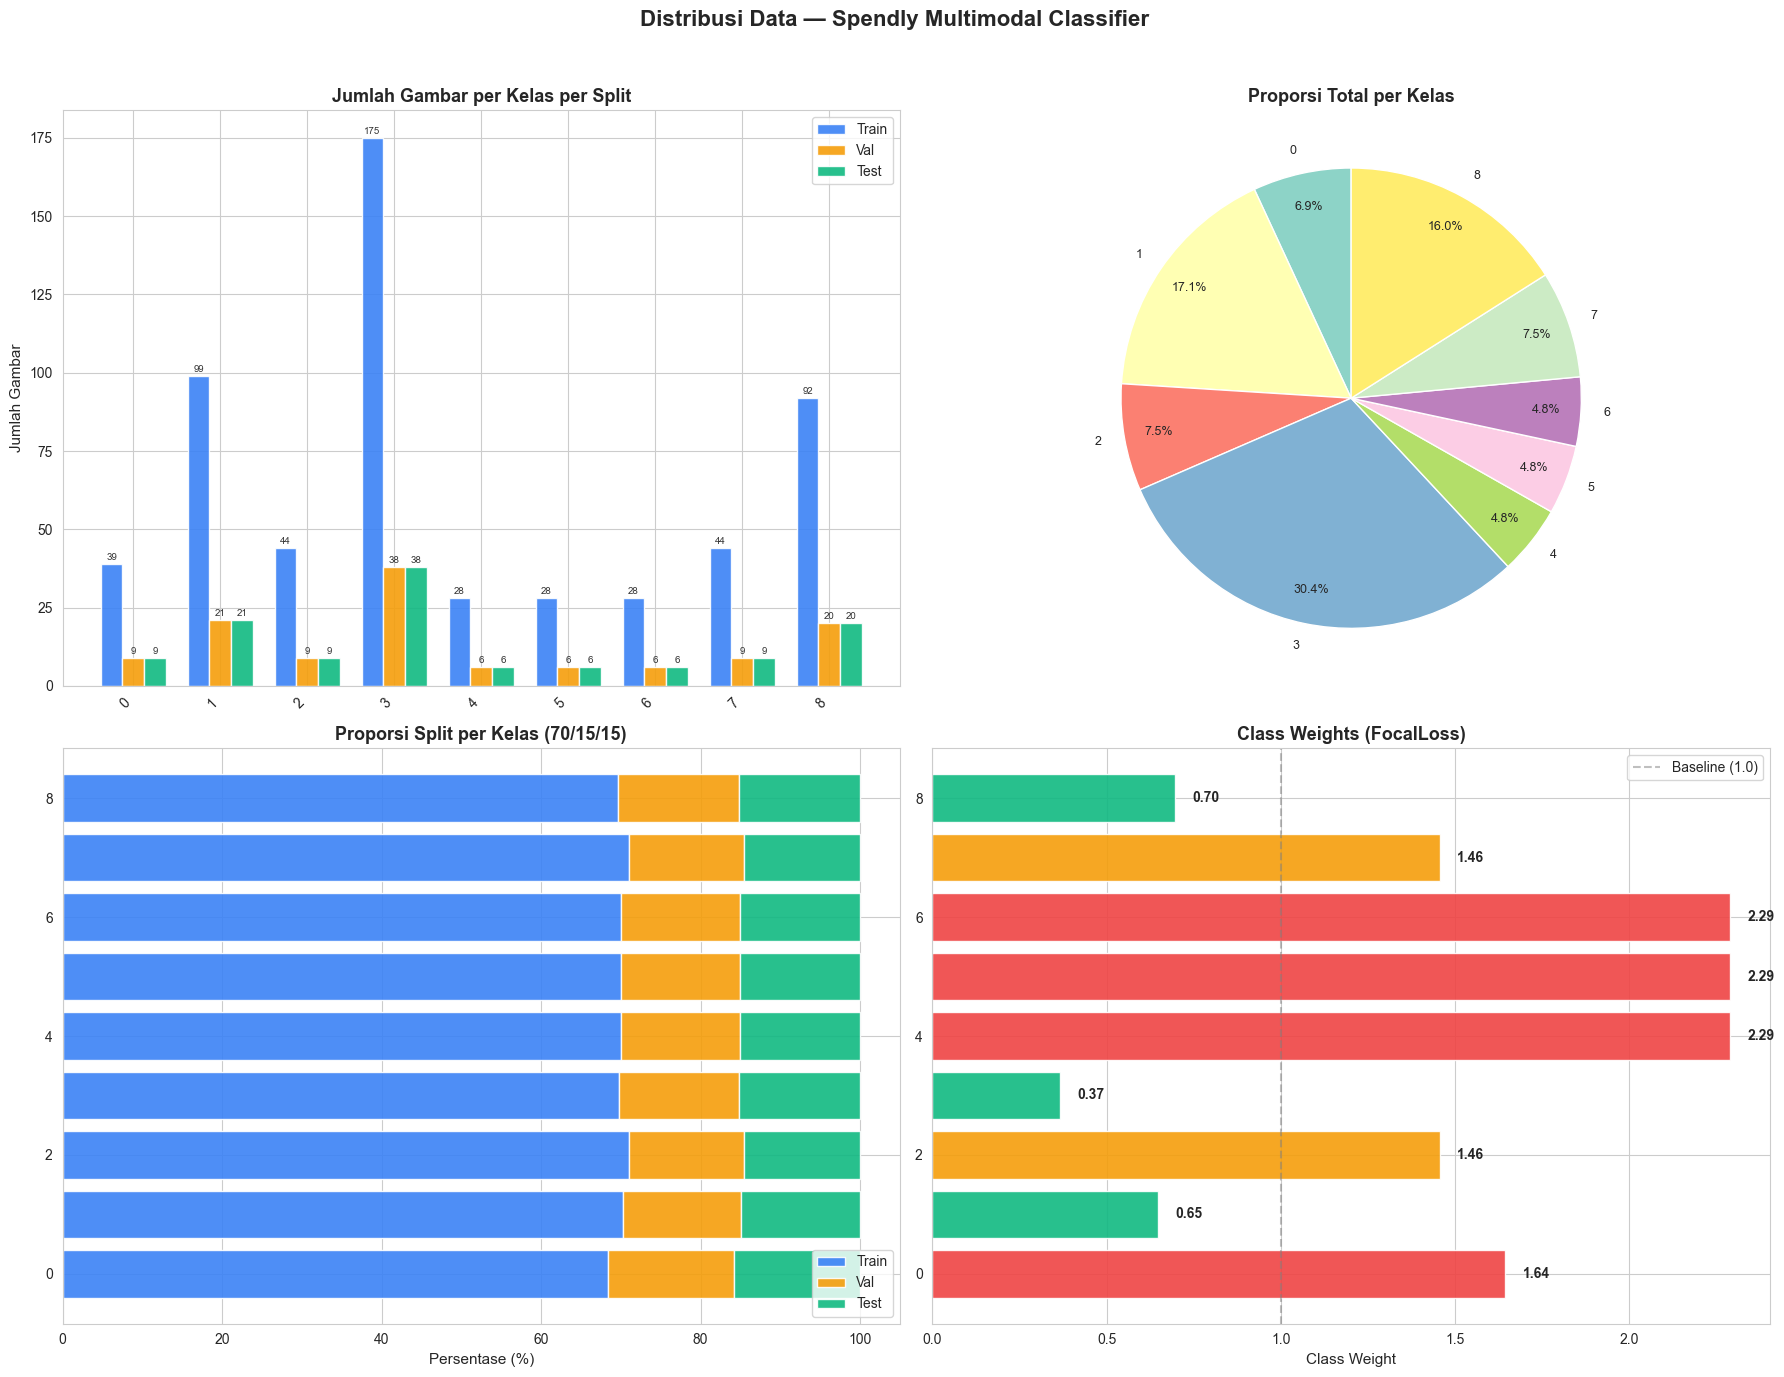


                 RINGKASAN DISTRIBUSI DATA                  
Kelas         Train    Val   Test  Total   Persen
--------------------------------------------------
0                39      9      9     57     6.9%
1                99     21     21    141    17.1%
2                44      9      9     62     7.5%
3               175     38     38    251    30.4%
4                28      6      6     40     4.8%
5                28      6      6     40     4.8%
6                28      6      6     40     4.8%
7                44      9      9     62     7.5%
8                92     20     20    132    16.0%
--------------------------------------------------
TOTAL           577    124    124    825   100.0%


In [11]:
# ══════════════════════════════════════════════════════════════════
# VISUALISASI SEBARAN DATA — Train / Val / Test
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Distribusi Data — Spendly Multimodal Classifier', fontsize=16, fontweight='bold', y=0.98)

# ── 1. Bar chart: jumlah per kelas per split ─────────────────────
ax1 = axes[0, 0]
train_counts = Counter(y_train)
val_counts   = Counter(y_val)
test_counts  = Counter(y_test)

# ✅ After
categories = sorted(set(np.concatenate([y_train, y_val, y_test])))
x = np.arange(len(categories))
width = 0.25

bars1 = ax1.bar(x - width, [train_counts.get(c, 0) for c in categories], width, label='Train', color='#3b82f6', alpha=0.9)
bars2 = ax1.bar(x,         [val_counts.get(c, 0)   for c in categories], width, label='Val',   color='#f59e0b', alpha=0.9)
bars3 = ax1.bar(x + width, [test_counts.get(c, 0)  for c in categories], width, label='Test',  color='#10b981', alpha=0.9)

ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Jumlah Gambar', fontsize=11)
ax1.set_title('Jumlah Gambar per Kelas per Split', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

# Tambah label angka di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax1.annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', fontsize=7, color='#333')

# ── 2. Pie chart: proporsi total per kelas ───────────────────────
ax2 = axes[0, 1]
# ✅ After
all_labels = np.concatenate([y_train, y_val, y_test])
total_counts = Counter(all_labels)
labels_sorted = sorted(total_counts.keys())
sizes  = [total_counts[c] for c in labels_sorted]
colors = plt.cm.Set3(np.linspace(0, 1, len(labels_sorted)))

wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels_sorted, autopct='%1.1f%%',
    colors=colors, startangle=90, pctdistance=0.85,
    textprops={'fontsize': 9}
)
ax2.set_title('Proporsi Total per Kelas', fontsize=13, fontweight='bold')

# ── 3. Stacked bar: proporsi split per kelas ─────────────────────
ax3 = axes[1, 0]
train_vals = [train_counts.get(c, 0) for c in categories]
val_vals   = [val_counts.get(c, 0)   for c in categories]
test_vals  = [test_counts.get(c, 0)  for c in categories]

# Normalize to percentage
totals = [t + v + te for t, v, te in zip(train_vals, val_vals, test_vals)]
train_pct = [t/tot*100 if tot > 0 else 0 for t, tot in zip(train_vals, totals)]
val_pct   = [v/tot*100 if tot > 0 else 0 for v, tot in zip(val_vals, totals)]
test_pct  = [te/tot*100 if tot > 0 else 0 for te, tot in zip(test_vals, totals)]

ax3.barh(categories, train_pct, label='Train', color='#3b82f6', alpha=0.9)
ax3.barh(categories, val_pct,   left=train_pct, label='Val', color='#f59e0b', alpha=0.9)
left2 = [t + v for t, v in zip(train_pct, val_pct)]
ax3.barh(categories, test_pct,  left=left2, label='Test', color='#10b981', alpha=0.9)
ax3.set_xlabel('Persentase (%)', fontsize=11)
ax3.set_title('Proporsi Split per Kelas (70/15/15)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10, loc='lower right')
ax3.set_xlim(0, 105)

# ── 4. Class weights visualization ────────────────────────────────
ax4 = axes[1, 1]
if 'class_weight_dict' in dir() or 'class_weight_dict' in globals():
    cw_labels = [categories[i] for i in sorted(class_weight_dict.keys())]
    cw_values = [class_weight_dict[i] for i in sorted(class_weight_dict.keys())]
    colors_cw = ['#ef4444' if v > 1.5 else '#f59e0b' if v > 1.0 else '#10b981' for v in cw_values]
    bars = ax4.barh(cw_labels, cw_values, color=colors_cw, alpha=0.9)
    ax4.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Baseline (1.0)')
    for bar, v in zip(bars, cw_values):
        ax4.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=10, fontweight='bold')
    ax4.set_xlabel('Class Weight', fontsize=11)
    ax4.set_title('Class Weights (FocalLoss)', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=10)
else:
    ax4.text(0.5, 0.5, 'Class weights belum dihitung', ha='center', va='center', fontsize=12)
    ax4.set_title('Class Weights', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'nb03_data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'{"RINGKASAN DISTRIBUSI DATA":^60}')
print(f'{"="*60}')
print(f'{"Kelas":<12} {"Train":>6} {"Val":>6} {"Test":>6} {"Total":>6} {"Persen":>8}')
print(f'{"-"*50}')
total_all = len(all_labels)
for c in categories:
    tr = train_counts.get(c, 0)
    va = val_counts.get(c, 0)
    te = test_counts.get(c, 0)
    tot = tr + va + te
    pct = tot / total_all * 100
    print(f'{c:<12} {tr:>6} {va:>6} {te:>6} {tot:>6} {pct:>7.1f}%')
print(f'{"-"*50}')
print(f'{"TOTAL":<12} {len(y_train):>6} {len(y_val):>6} {len(y_test):>6} {total_all:>6} {100.0:>7.1f}%')


## 3.2c — tf.data Pipeline + Image Augmentation

In [12]:
BATCH_SIZE = 32  # Keep 32 — dataset terlalu kecil untuk 64

# ── Augmentasi gambar hanya untuk training ──────────────────────────────────
@tf.function
def augment_image(image):
    """Augmentasi ringan untuk training: flip, brightness, contrast, rotation."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    # Rotasi kecil via crop-and-resize sebagai proxy
    image = tf.image.random_crop(
        tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 20, IMG_SIZE + 20),
        size=[IMG_SIZE, IMG_SIZE, 3]
    )
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

@tf.function
def augment_train_sample(inputs, label):
    text_x, img_x = inputs
    img_x = augment_image(img_x)
    return (text_x, img_x), label

train_ds = (
    tf.data.Dataset.from_tensor_slices(((X_train_text, X_train_img), y_train_oh))
    .shuffle(1000, seed=SEED)
    .map(augment_train_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices(((X_val_text, X_val_img), y_val_oh))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices(((X_test_text, X_test_img), y_test_oh))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("✅ tf.data datasets created (dengan image augmentation di training)")

✅ tf.data datasets created (dengan image augmentation di training)


## 3.3 — Build Multimodal Classifier v3 (Functional API + SEBlock)

**Architecture v3:**
- Branch 1 (Text): TF-IDF → Dense(256) → BN → Dropout → Dense(128) → Dropout
- Branch 2 (CNN):  4x [Conv2D → BN → SEBlock → MaxPool] → GAP → Dense(256) → Dropout
- Fusion: Concatenate → Dense(256) → BN → Dropout → Dense(128) → Dense(9, Softmax)

SEBlock adalah custom layer dari scratch (bukan pretrained) yang memperkuat
channel-wise feature responses di tiap Conv block.

In [13]:
from custom_components import SEBlock, FocalLoss, SpendlyCallback

def build_multimodal_classifier_v3(n_text_features, n_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """Multimodal Classifier v3 — Optimized for small dataset (~600 samples).

    CNN branch: 4 Conv block + SEBlock + strong regularization.
    Text branch: 256→128 (matching dataset scale).
    Semua weights ditraining dari nol — tidak menggunakan pretrained model manapun.
    """
    reg = tf.keras.regularizers.l2(5e-4)  # stronger L2 (was 1e-4)

    # ── Text Branch ──────────────────────────────────────────────────────────
    text_input = tf.keras.Input(shape=(n_text_features,), name="text_input")
    t = layers.Dense(256, activation='relu', kernel_regularizer=reg)(text_input)
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(0.5)(t)
    t = layers.Dense(128, activation='relu', kernel_regularizer=reg)(t)
    t = layers.Dropout(0.4)(t)

    # ── CNN Branch (4 block + SEBlock + strong reg) ──────────────────────────
    img_input = tf.keras.Input(shape=(img_size, img_size, 3), name="image_input")

    # Block 1: 32 filter
    c = layers.Conv2D(32, (3, 3), padding='same', use_bias=False, kernel_regularizer=reg)(img_input)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = SEBlock(ratio=8, name='se_block_1')(c)
    c = layers.MaxPooling2D((2, 2))(c)
    c = layers.Dropout(0.15)(c)

    # Block 2: 64 filter
    c = layers.Conv2D(64, (3, 3), padding='same', use_bias=False, kernel_regularizer=reg)(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = SEBlock(ratio=8, name='se_block_2')(c)
    c = layers.MaxPooling2D((2, 2))(c)
    c = layers.Dropout(0.15)(c)

    # Block 3: 128 filter
    c = layers.Conv2D(128, (3, 3), padding='same', use_bias=False, kernel_regularizer=reg)(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = SEBlock(ratio=8, name='se_block_3')(c)
    c = layers.MaxPooling2D((2, 2))(c)
    c = layers.Dropout(0.2)(c)

    # Block 4: 256 filter
    c = layers.Conv2D(256, (3, 3), padding='same', use_bias=False, kernel_regularizer=reg)(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = SEBlock(ratio=8, name='se_block_4')(c)
    c = layers.GlobalAveragePooling2D()(c)

    c = layers.Dense(128, activation='relu', kernel_regularizer=reg)(c)
    c = layers.Dropout(0.5)(c)

    # ── Fusion ───────────────────────────────────────────────────────────────
    fused   = layers.Concatenate()([t, c])  # 128 + 128 = 256
    f       = layers.Dense(256, activation='relu', kernel_regularizer=reg)(fused)
    f       = layers.BatchNormalization()(f)
    f       = layers.Dropout(0.5)(f)
    f       = layers.Dense(128, activation='relu', kernel_regularizer=reg)(f)
    f       = layers.Dropout(0.4)(f)
    outputs = layers.Dense(n_classes, activation='softmax', name="output")(f)

    return Model(
        inputs=[text_input, img_input],
        outputs=outputs,
        name="spendly_multimodal_classifier_v3"
    )


model = build_multimodal_classifier_v3(actual_features)
model.summary()
print(f"\nOutput shape: {model.output_shape}  (expected: (None, {NUM_CLASSES}))")

Model: "spendly_multimodal_classifier_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 224, 224, 32  864         ['image_input[0][0]']            
                                )                                                                 
                                                                                                  
 batch_normalization_1 (BatchNo  (None, 224, 224, 32  128        ['conv2d[0][0]']                 
 rmalization)                   )                                  

## 3.4 — Training dengan tf.GradientTape + FocalLoss + SpendlyCallback

In [14]:
# ── Loss dengan per-class weights ────────────────────────────────────────────
loss_fn   = FocalLoss(gamma=2.0, alpha=0.25, class_weights=class_weight_dict)

EPOCHS       = 200

# LR lebih rendah + gradient clipping untuk stabilitas
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)

# ── TensorBoard writers ──────────────────────────────────────────────────────
log_dir = os.path.join(PROJECT_ROOT, 'logs', 'classifier')
os.makedirs(os.path.join(log_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(log_dir, 'val'),   exist_ok=True)
train_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'train'))
val_writer   = tf.summary.create_file_writer(os.path.join(log_dir, 'val'))

# ── SpendlyCallback di-wire ke manual loop ───────────────────────────────────
spendly_cb = SpendlyCallback(
    model_name='classifier',
    patience=25,
    min_delta=0.001,
    save_dir=os.path.join(PROJECT_ROOT, 'models'),
    mode='manual'
)
spendly_cb.set_model(model)  # set model reference manually

# ── Train/Val step functions ─────────────────────────────────────────────────
@tf.function
def train_step(text_x, img_x, y):
    y = tf.cast(y, tf.float32)  # ← tambah ini
    with tf.GradientTape() as tape:
        preds = model([text_x, img_x], training=True)
        preds = tf.cast(preds, tf.float32)  # ← dan ini
        loss  = loss_fn(y, preds)
        loss += tf.reduce_sum(model.losses)
    grads = tape.gradient(loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 5.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, preds

@tf.function
def val_step(text_x, img_x, y):
    y = tf.cast(y, tf.float32)  # ← tambah ini
    preds = model([text_x, img_x], training=False)
    preds = tf.cast(preds, tf.float32)  # ← dan ini
    loss  = loss_fn(y, preds)
    return loss, preds

# ── Training Loop ────────────────────────────────────────────────────────────
history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0


print("=" * 70)
print(f"MULTIMODAL CLASSIFIER TRAINING v3 — {NUM_CLASSES} kategori")
print("CNN (4 block + SEBlock) + TF-IDF, FocalLoss + class weights, GradientTape")
print("=" * 70)

for epoch in range(EPOCHS):
    t0   = time.time()
    tl_m = tf.keras.metrics.Mean()
    ta_m = tf.keras.metrics.CategoricalAccuracy()

    for (text_x, img_x), y in train_ds:
        loss, preds = train_step(text_x, img_x, y)
        tl_m.update_state(loss)
        ta_m.update_state(y, preds)

    vl_m = tf.keras.metrics.Mean()
    va_m = tf.keras.metrics.CategoricalAccuracy()

    for (text_x, img_x), y in val_ds:
        loss, preds = val_step(text_x, img_x, y)
        vl_m.update_state(loss)
        va_m.update_state(y, preds)

    tl, ta  = tl_m.result().numpy(), ta_m.result().numpy()
    vl, va  = vl_m.result().numpy(), va_m.result().numpy()
    elapsed = time.time() - t0

    history['train_loss'].append(tl)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)

    # TensorBoard logging
    with train_writer.as_default():
        tf.summary.scalar("loss",     tl, step=epoch)
        tf.summary.scalar("accuracy", ta, step=epoch)
    with val_writer.as_default():
        tf.summary.scalar("loss",     vl, step=epoch)
        tf.summary.scalar("accuracy", va, step=epoch)

    # Update best_val_acc untuk laporan akhir
    if va > best_val_acc:
        best_val_acc = va

    # SpendlyCallback — early stop + save best model
    should_stop = spendly_cb.on_epoch_end_manual(
        epoch,
        logs={
            'train_loss': tl, 'train_acc': ta,
            'val_loss':   vl, 'val_acc':   va,
            'loss': tl, 'accuracy': ta,
            'val_accuracy': va
        }
    )
    if should_stop:
        print(f"  [Loop] Early stop triggered. Keluar dari training loop.")
        break

print(f"\nTraining selesai. Best val_acc: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

MULTIMODAL CLASSIFIER TRAINING v3 — 9 kategori
CNN (4 block + SEBlock) + TF-IDF, FocalLoss + class weights, GradientTape
[SpendlyCallback] Epoch   1 | loss=1.9817 acc=0.1282 | val_loss=0.7529 val_acc=0.1694 | best=0.1694 patience=0/25  ← BEST saved (c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\classifier\classifier.keras)
[SpendlyCallback] Epoch   2 | loss=1.6921 acc=0.2080 | val_loss=0.7525 val_acc=0.1694 | best=0.1694 patience=1/25
[SpendlyCallback] Epoch   3 | loss=1.5681 acc=0.2392 | val_loss=0.7556 val_acc=0.1613 | best=0.1694 patience=2/25
[SpendlyCallback] Epoch   4 | loss=1.5247 acc=0.3016 | val_loss=0.7584 val_acc=0.1613 | best=0.1694 patience=3/25
[SpendlyCallback] Epoch   5 | loss=1.3993 acc=0.3241 | val_loss=0.7665 val_acc=0.1613 | best=0.1694 patience=4/25
[SpendlyCallback] Epoch   6 | loss=1.3837 acc=0.3293 | val_loss=0.7895 val_acc=0.1613 | best=0.1694 patience=5/25
[SpendlyCallback] Epoch   7 | loss=1.2228 acc=0.3830 | val_loss=0.8378 val_acc=0.1613 | bes

## 3.5 — Training Curves

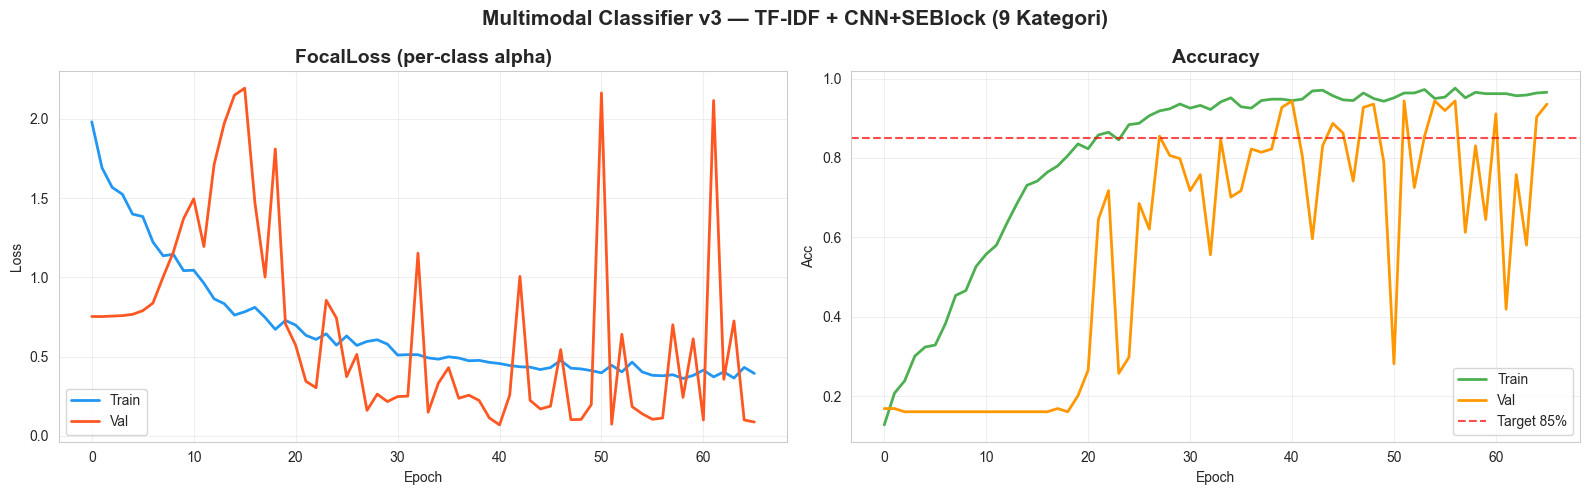

✅ Training curves saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history['train_loss'], label='Train', color='#2196F3', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   color='#FF5722', linewidth=2)
axes[0].set_title('FocalLoss (per-class alpha)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', color='#4CAF50', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   color='#FF9800', linewidth=2)
axes[1].axhline(y=0.85, color='red', linestyle='--', alpha=0.7, label='Target 85%')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(
    'Multimodal Classifier v3 — TF-IDF + CNN+SEBlock (9 Kategori)',
    fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(
    os.path.join(PROJECT_ROOT, 'data', '_processed', 'classifier_training_curves_v3.png'),
    dpi=150)
plt.show()
print("✅ Training curves saved.")

## 3.6 — Test Evaluation

In [16]:
# Load best weights yang disimpan SpendlyCallback
best_model_path = os.path.join(PROJECT_ROOT, 'models', 'classifier', 'classifier.keras')
if os.path.exists(best_model_path):
    model = tf.keras.models.load_model(
        best_model_path,
        custom_objects={'SEBlock': SEBlock, 'FocalLoss': FocalLoss}
    )
    print(f"✅ Loaded best model dari SpendlyCallback: {best_model_path}")
else:
    print("⚠️  Best model tidak ditemukan, pakai model terakhir")

all_preds, all_trues = [], []
for (text_x, img_x), y in test_ds:
    preds = model([text_x, img_x], training=False)
    all_preds.extend(tf.argmax(preds, axis=1).numpy())
    all_trues.extend(tf.argmax(y,     axis=1).numpy())

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)
test_acc  = np.mean(all_preds == all_trues)

print("=" * 65)
print("CLASSIFICATION REPORT (Test Set) — v3 (9 Kategori)")
print("=" * 65)
unique_labels = sorted(set(all_trues) | set(all_preds))
target_names  = [LABELS[i] for i in unique_labels]
print(classification_report(
    all_trues, all_preds,
    labels=unique_labels,
    target_names=target_names,
    digits=4
))
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
if test_acc >= 0.85:
    print("✅ TARGET MET (>= 85%)")
else:
    print(f"⚠️  TARGET NOT MET (need >= 85%, got {test_acc*100:.2f}%)")

✅ Loaded best model dari SpendlyCallback: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\classifier\classifier.keras
CLASSIFICATION REPORT (Test Set) — v3 (9 Kategori)
              precision    recall  f1-score   support

      Beauty     0.9000    1.0000    0.9474         9
         F&B     0.9524    0.9524    0.9524        21
         Gas     1.0000    0.7778    0.8750         9
   Groceries     1.0000    0.8947    0.9444        38
      Health     0.8333    0.8333    0.8333         6
   HouseHold     1.0000    1.0000    1.0000         6
   Lifestyle     0.6000    1.0000    0.7500         6
     Listrik     1.0000    1.0000    1.0000         9
   transport     0.9524    1.0000    0.9756        20

    accuracy                         0.9355       124
   macro avg     0.9153    0.9398    0.9198       124
weighted avg     0.9496    0.9355    0.9379       124

Test Accuracy: 0.9355 (93.55%)
✅ TARGET MET (>= 85%)


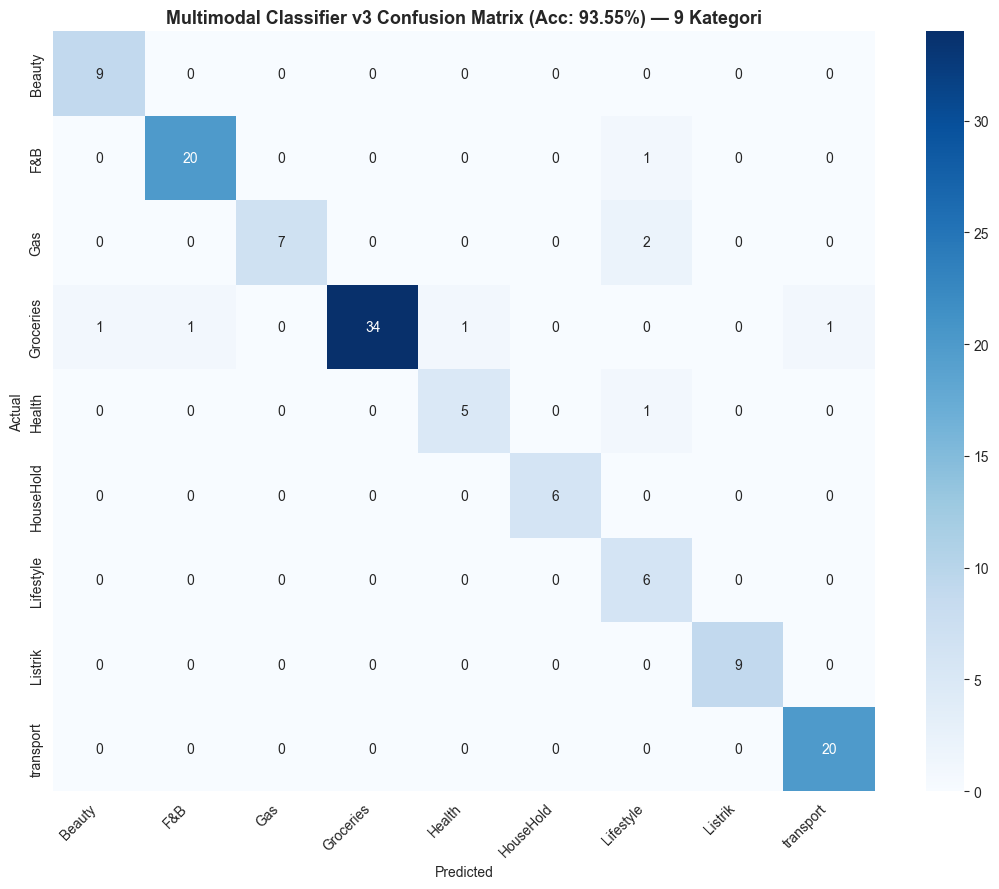

✅ Confusion matrix saved.


In [17]:
cm  = confusion_matrix(all_trues, all_preds)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABELS[i] for i in unique_labels],
            yticklabels=[LABELS[i] for i in unique_labels], ax=ax)
ax.set_title(
    f'Multimodal Classifier v3 Confusion Matrix (Acc: {test_acc:.2%}) — 9 Kategori',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(
    os.path.join(PROJECT_ROOT, 'data', '_processed', 'classifier_confusion_matrix_v3.png'),
    dpi=150)
plt.show()
print("✅ Confusion matrix saved.")

## 3.7 — Save Final Model

In [18]:
model.save(os.path.join(save_dir, 'classifier.keras'))
tf.saved_model.save(model, os.path.join(save_dir, 'classifier_saved'))
print("✅ Model saved: classifier.keras + classifier_saved/")

INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\classifier\classifier_saved\assets


INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\classifier\classifier_saved\assets


✅ Model saved: classifier.keras + classifier_saved/


In [19]:
print(f"""
=====================================================
LAPORAN: Notebook 03 v3 — Multimodal Classifier
=====================================================

v3 CHANGES (dari v2):
- CNN branch: 3 block → 4 block, tambah SEBlock (custom layer) tiap block
- Image augmentation di tf.data pipeline (flip, brightness, contrast, crop)
- Augmentasi OCR noise di text branch training (noise_prob=0.15)
- FocalLoss: scalar alpha → per-class alpha dari class_weights
- SpendlyCallback di-wire ke GradientTape via on_epoch_end_manual()
- Class weights dihitung dari distribusi aktual (compute_class_weight)

ARSITEKTUR:
- Text  : TF-IDF({actual_features}) → Dense(256) → BN → Dense(128)
- Image : [Conv2D(32→64→128→256) + BN + SEBlock + MaxPool] → GAP → Dense(256→128)
- Fusion: Concat → Dense(256) → BN → Dense(128) → Dense(9, Softmax)
- Loss  : FocalLoss gamma=2.0, per-class alpha dari class_weights
- Optim : Adam lr=1e-3, EarlyStopping patience=25 (via SpendlyCallback)

HASIL:
- Best Val Accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)
- Test Accuracy     : {test_acc:.4f} ({test_acc*100:.2f}%)

OUTPUT FILES:
- models/classifier/classifier.keras
- models/classifier/classifier_saved/
- models/classifier/nlp_preprocessor.joblib
- models/classifier/tfidf_vectorizer.joblib
- logs/classifier/train/  (TensorBoard)
- logs/classifier/val/    (TensorBoard)
=====================================================
""")


LAPORAN: Notebook 03 v3 — Multimodal Classifier

v3 CHANGES (dari v2):
- CNN branch: 3 block → 4 block, tambah SEBlock (custom layer) tiap block
- Image augmentation di tf.data pipeline (flip, brightness, contrast, crop)
- Augmentasi OCR noise di text branch training (noise_prob=0.15)
- FocalLoss: scalar alpha → per-class alpha dari class_weights
- SpendlyCallback di-wire ke GradientTape via on_epoch_end_manual()
- Class weights dihitung dari distribusi aktual (compute_class_weight)

ARSITEKTUR:
- Text  : TF-IDF(5000) → Dense(256) → BN → Dense(128)
- Image : [Conv2D(32→64→128→256) + BN + SEBlock + MaxPool] → GAP → Dense(256→128)
- Fusion: Concat → Dense(256) → BN → Dense(128) → Dense(9, Softmax)
- Loss  : FocalLoss gamma=2.0, per-class alpha dari class_weights
- Optim : Adam lr=1e-3, EarlyStopping patience=25 (via SpendlyCallback)

HASIL:
- Best Val Accuracy : 0.9435 (94.35%)
- Test Accuracy     : 0.9355 (93.55%)

OUTPUT FILES:
- models/classifier/classifier.keras
- models/classifier/